In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from keras import layers
from keras import regularizers
import random
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, cross_val_score
import h5py


In [4]:
def h5_to_dataframe(file_path, dataframe):
    ''' 
    Function for converting h5 file to a pandas dataframe for analysis 
    file_path: path to the h5 file, must be a string
    Dataframe_name: name of the pre-defined dataframe
    
    '''
    with h5py.File(file_path, mode='r') as file:
        tasks_group = file['tasks']
    
        keys = list(tasks_group.keys())
        keys.remove('visc_dissip')
        keys.remove('Reavg')
        time = np.array(file['scales']['sim_time'])
        for key in keys:
            name = np.array(file['tasks'][key][:,0,0])
            #print(name)
            dataframe[key] = name.tolist()

        dataframe['time'] = time.tolist()

    return dataframe

In [5]:
dataframes = []
dataframes2 = []
dataframes3 = []
for exponent in range(4, 9):  # 1e4 to 1e9
    for v in [1, 3, 5, 8]:
        var_name = f"R_{v}e{exponent}"
        globals()[var_name] = pd.DataFrame()
        dataframes.append(globals()[var_name])

        var_name2 = f"R2_{v}e{exponent}"
        globals()[var_name2] = pd.DataFrame()
        dataframes2.append(globals()[var_name2])

        var_name3 = f"R3_{v}e{exponent}"
        globals()[var_name3] = pd.DataFrame()
        dataframes3.append(globals()[var_name3])
        
values = [1, 3, 5, 8]
rayleigh_nums = []
file_path = []
file_path2 = []
file_path3 = []

for power in range(4, 9):  # From 10^4 to 10^9
    base = 10**power
    for v in values:
        rayleigh_nums.append(v * base)
        file_path.append(f"Free_slip_data/FS_analysis_{v * base:.0e}/FS_analysis_{v * base:.0e}_s1.h5")
        file_path2.append(f"Free_slip_data/FS_analysis2_{v * base:.0e}/FS_analysis2_{v * base:.0e}_s1.h5")
        file_path3.append(f"Free_slip_data/FS_analysis3_{v * base:.0e}/FS_analysis3_{v * base:.0e}_s1.h5")


dfs = [dataframes, dataframes2, dataframes3]
file_paths = [file_path, file_path2, file_path3]

for x, df in enumerate(dfs):
    for a, i in enumerate(df):
        h5_to_dataframe(file_paths[x][a], i)


df_clean = []

for df in dfs:
    for x, i in enumerate(df):
        if len(i) == 1600:
            Ral_num = np.ones(1600)*rayleigh_nums[x]
            i['Ra_num'] = Ral_num.tolist()
            df_clean.append(i)
        else:
            i = i.drop(i.tail(1).index)
            Ral_num = np.ones(1600)*rayleigh_nums[x]
            i['Ra_num'] = Ral_num.tolist()
            df_clean.append(i)

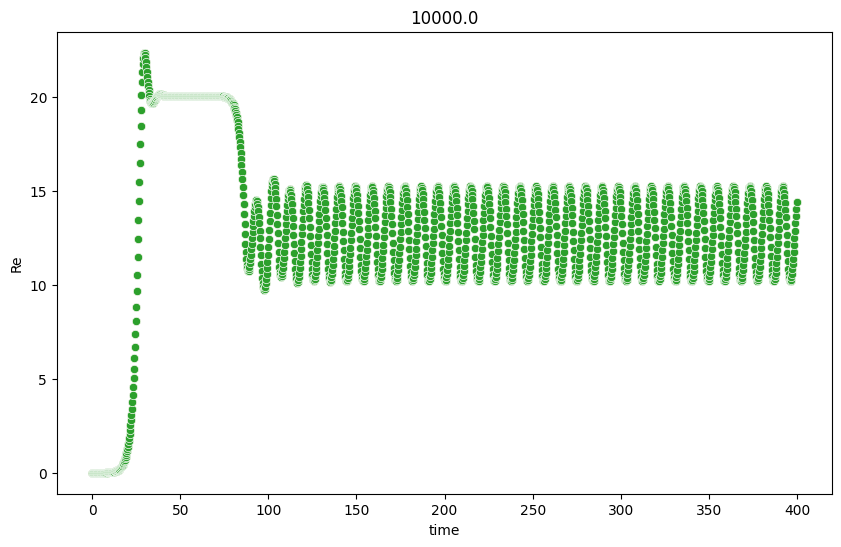

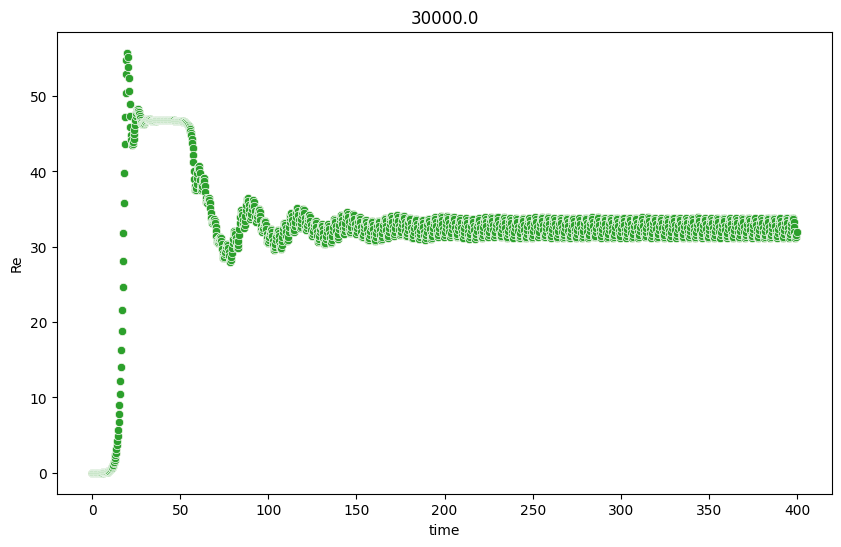

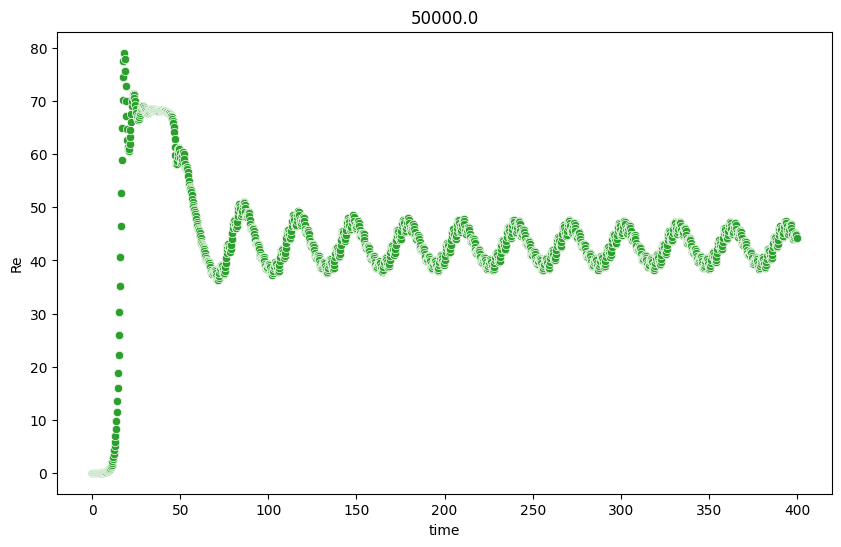

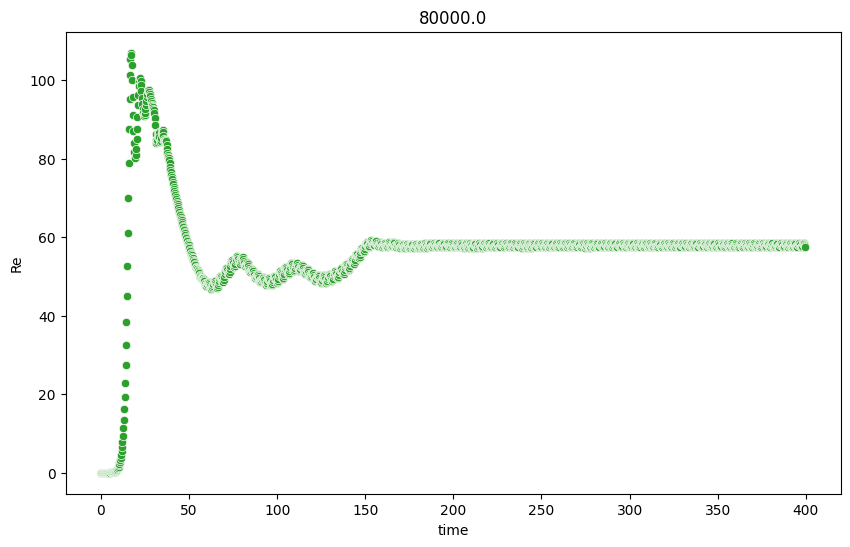

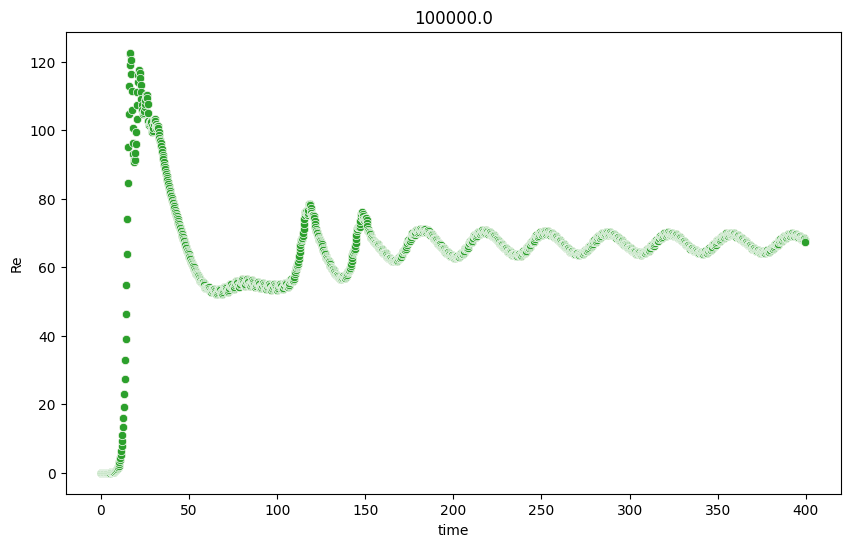

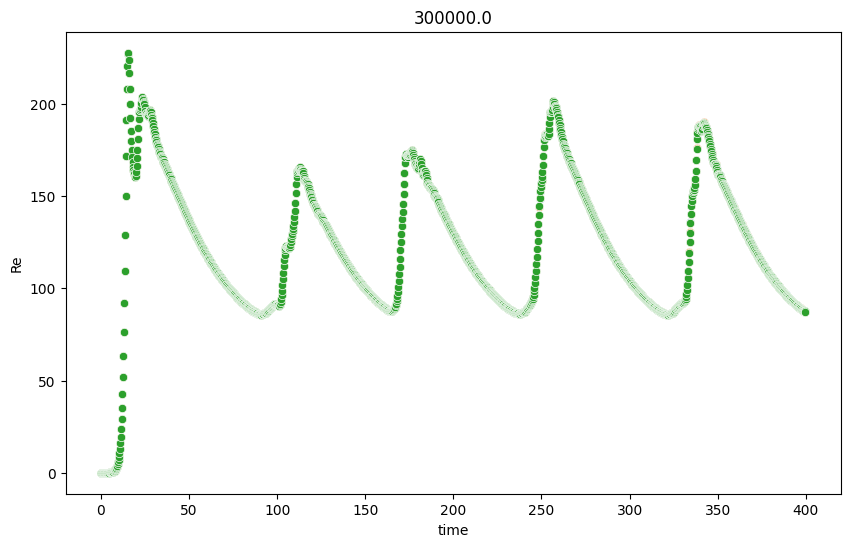

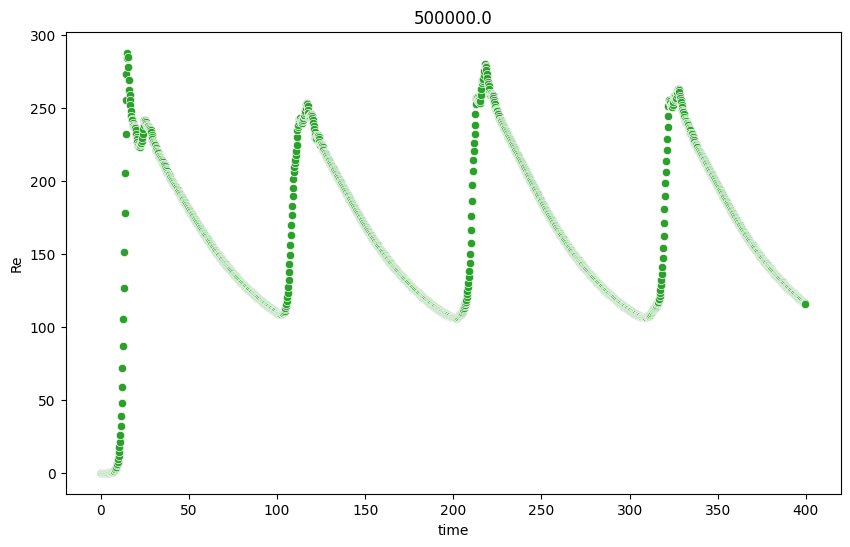

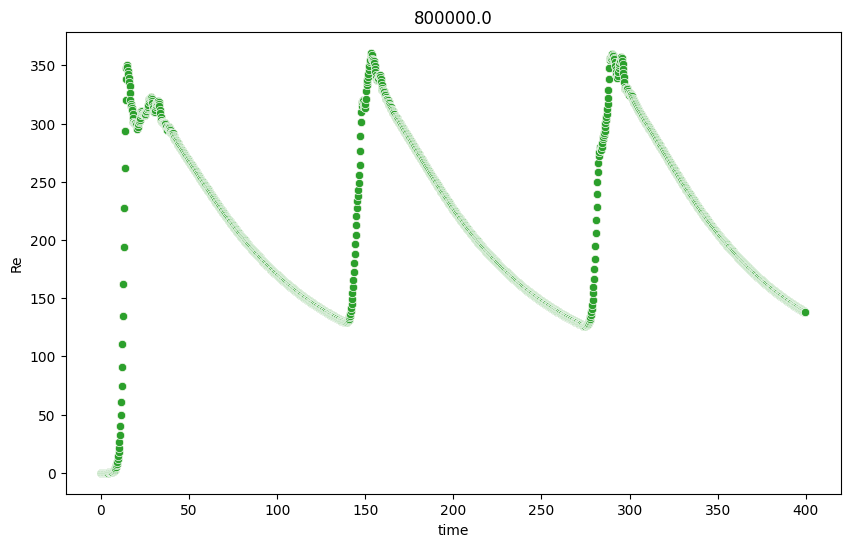

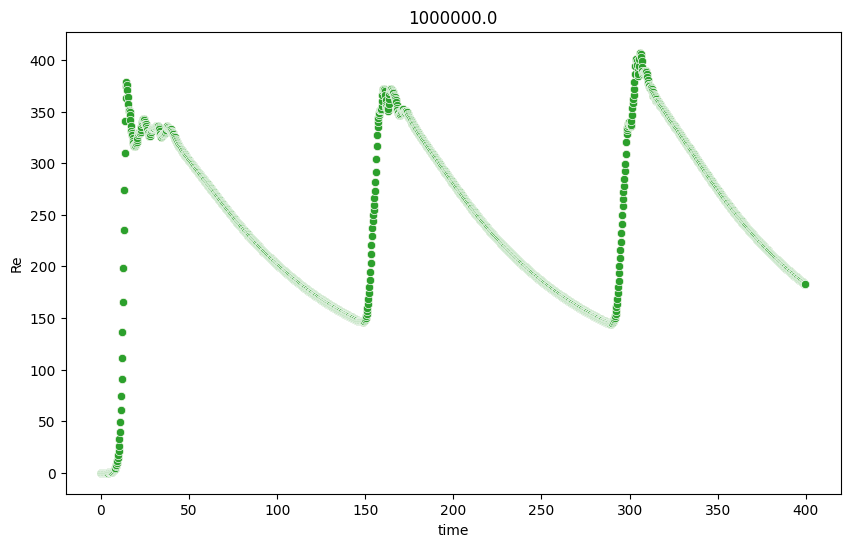

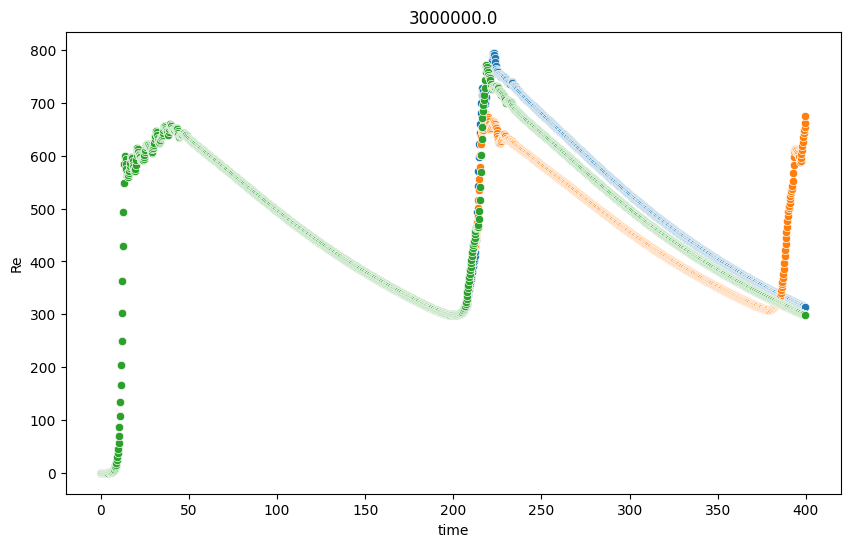

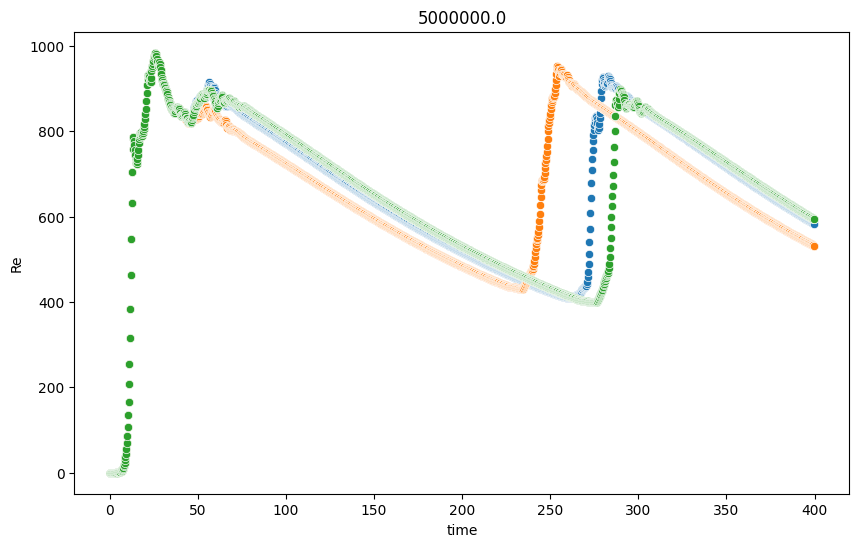

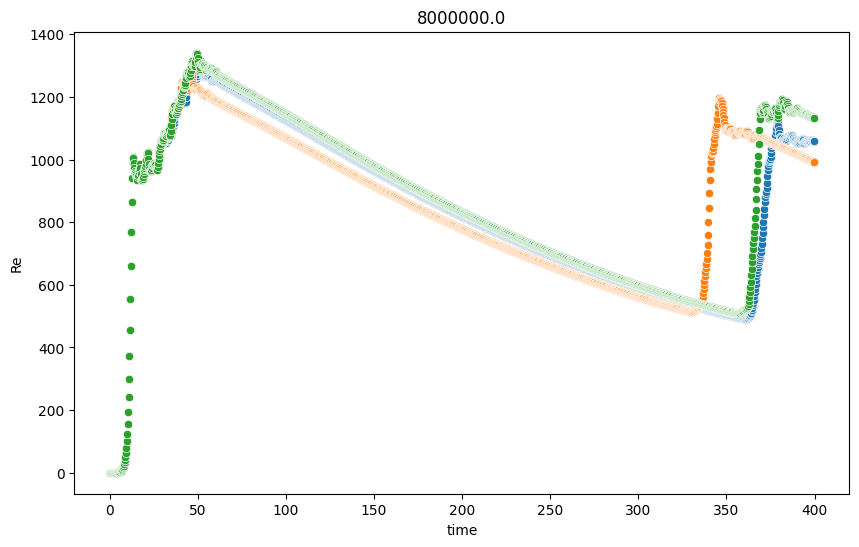

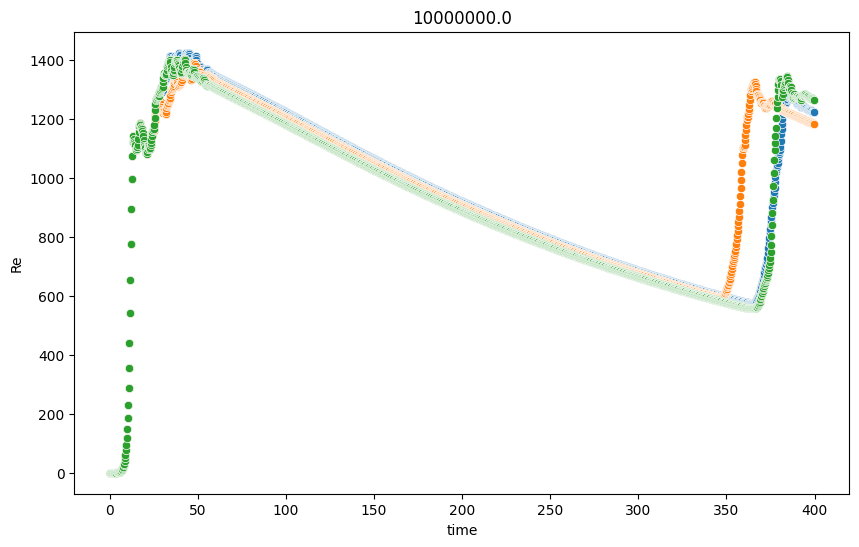

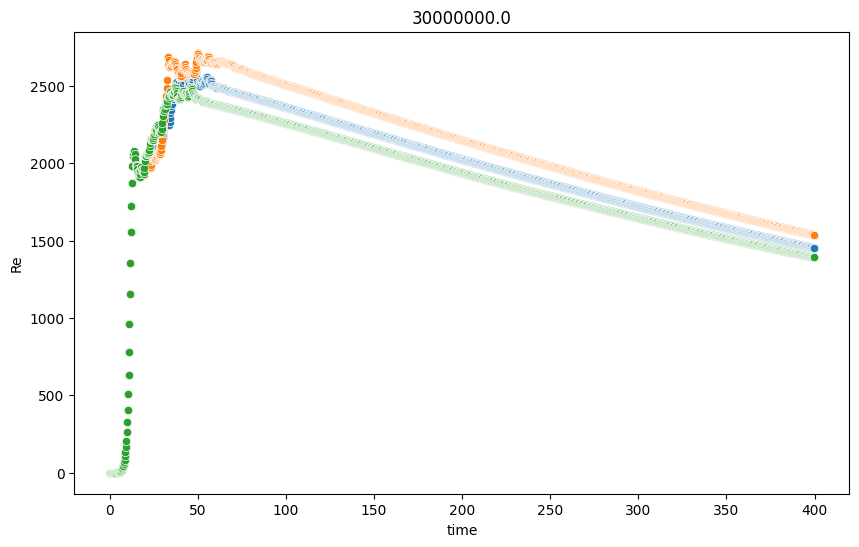

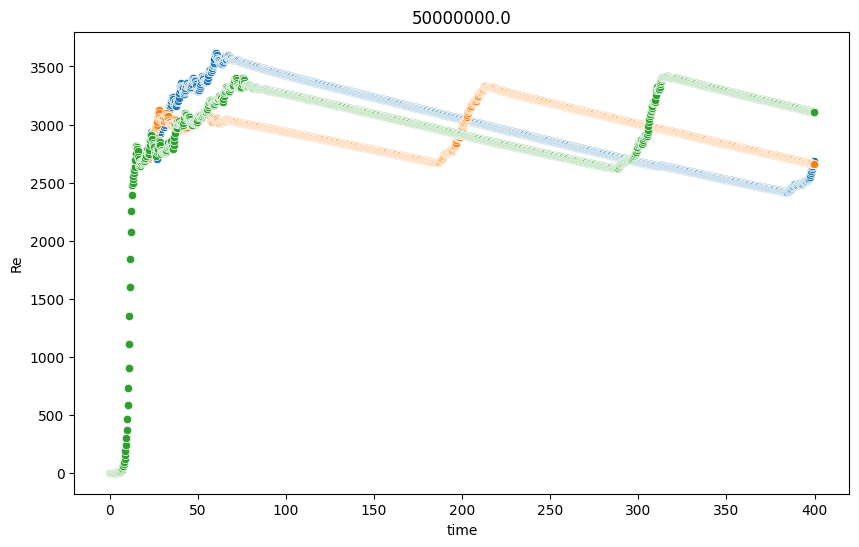

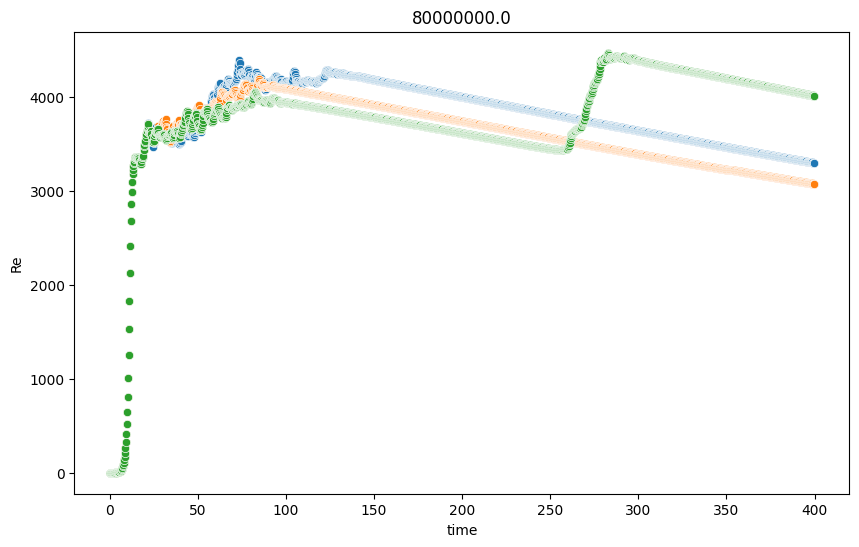

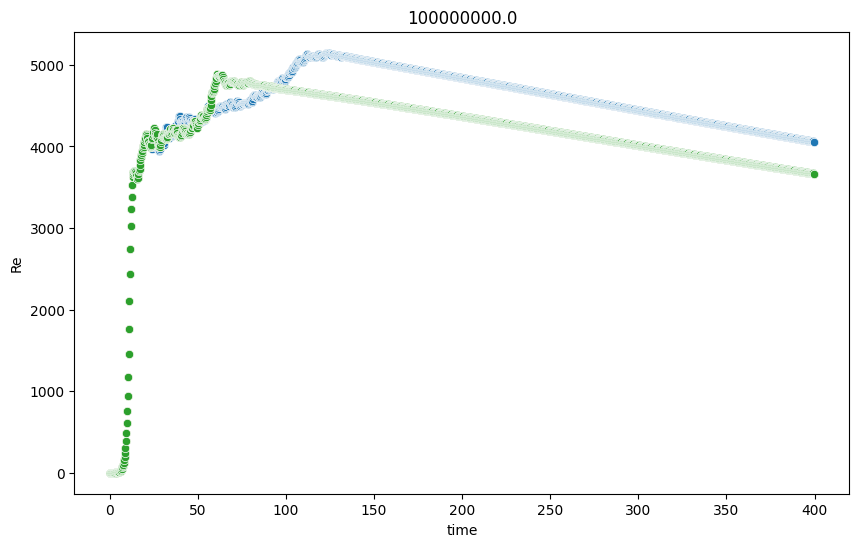

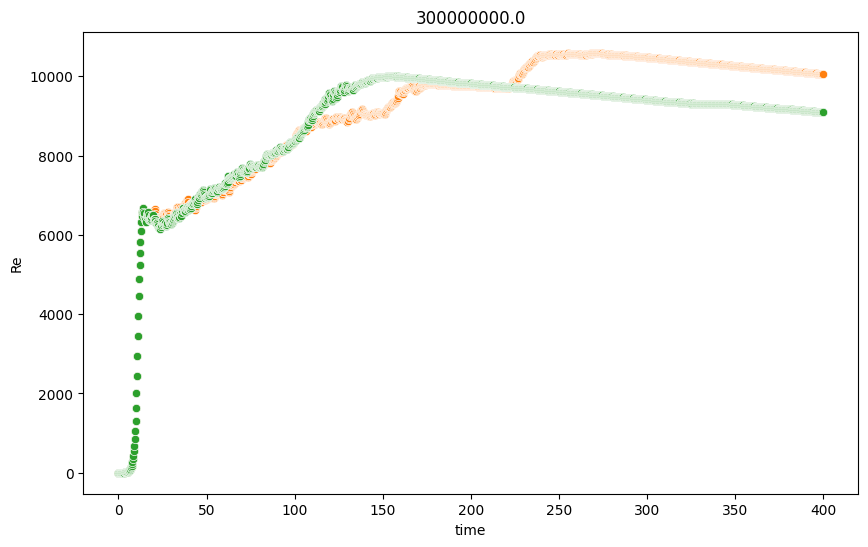

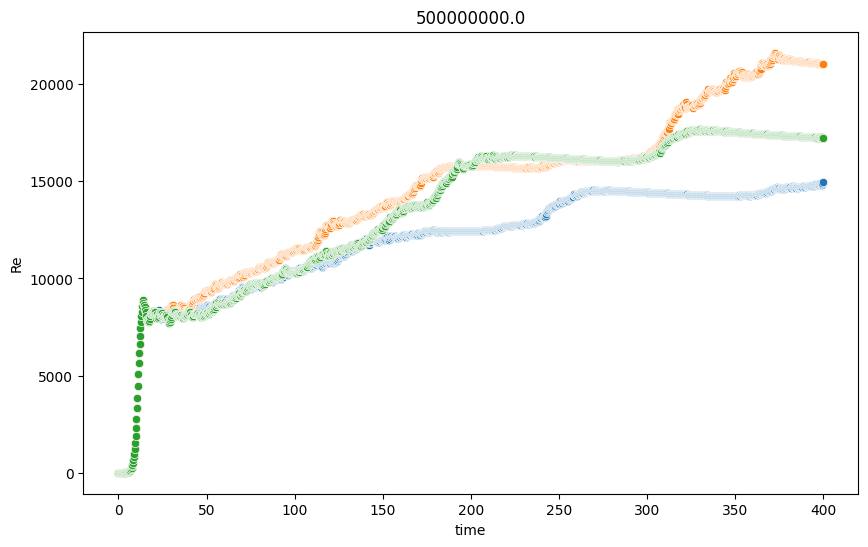

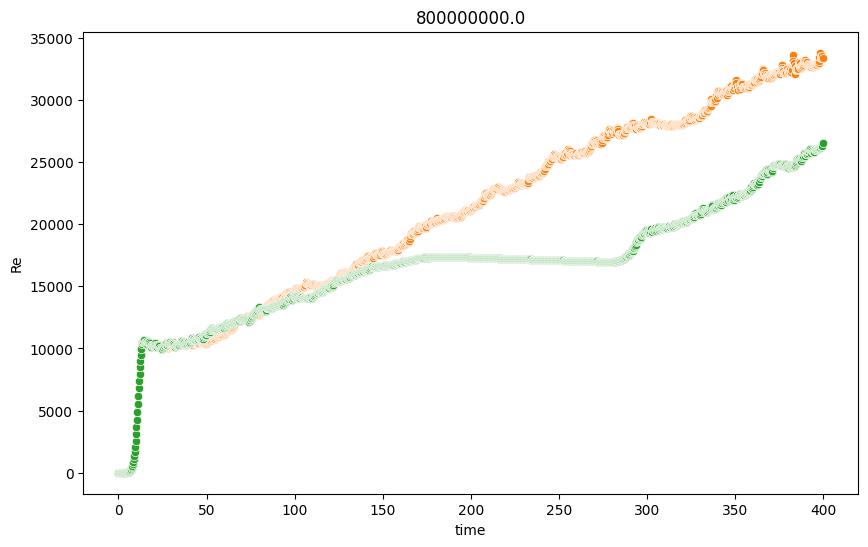

In [6]:
for i in range(0, 20, 1):
    a = i + 20
    b = i + 40
    plt.figure(figsize=(10, 6))
    plt.title(df_clean[i]['Ra_num'][0])
    sns.scatterplot(x = df_clean[i]['time'], y = df_clean[i]['Re'])
    sns.scatterplot(x = df_clean[a]['time'], y = df_clean[a]['Re'])
    sns.scatterplot(x = df_clean[b]['time'], y = df_clean[b]['Re'])

In [7]:
low = dataframes[0: 4]
burst = dataframes[5: 15]
high = dataframes[15: 20]

In [8]:
# Merge datasets
data = pd.concat(df_clean, ignore_index=True)

# Sort data by Rayleigh number and time for consistency
data = data.sort_values(by=["Ra_num", "time"]).reset_index(drop=True)

# Extract the relevant fields 
target = ["Re"]
features = ['time', 'Ra_num']

low_data = data[0: 24000]
burst_data = data[24000: 72000]
high_data = data[72000: 96000]

In [9]:
# Heteroscedastic loss function (adjusted for log-transformed target)
def heteroscedastic_loss(y_true, y_pred):
    mu = y_pred[:, 0]  # Mean prediction (log-space)
    log_var = y_pred[:, 1]
    precision = tf.exp(log_var)  # Inverse variance
    return tf.reduce_mean(0.5 * (tf.math.log(2 * np.pi) + log_var + (y_true - mu) ** 2 / precision))

In [10]:

def neural_network(x_data, y_data, learning_rate, regularisation, loss_function, SEED = None):
    np.random.seed(SEED)
    tf.random.set_seed(SEED)
    random.seed(SEED)

    scaler = StandardScaler()
    scaler_y = StandardScaler()
    #Low regime
    X_train = x_data
    y_train = y_data
    # Standardize features 
    X_train = scaler.fit_transform(X_train)

    # Log-transform the target and scale it
    log_y = np.log1p(y_train)
    y_train_log = scaler_y.fit_transform(log_y.values.reshape(-1, 1)).flatten()

    # Build the neural network
    input_layer = keras.Input(shape=(2,))
    x = layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(regularisation))(input_layer)
    x = layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(regularisation))(x)
    x = layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(regularisation))(x)
    x = layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(regularisation))(x)

    #x = layers.Dropout(0.2)(x)  
    output_layer = layers.Dense(2)(x)  # Two outputs: mean and log variance

    model = keras.Model(inputs=input_layer, outputs=output_layer)
    model.compile(optimizer=keras.optimizers.Adam(learning_rate= learning_rate), loss= loss_function)


    # Train the model with validation split
    model.fit(X_train, y_train_log, epochs=100, batch_size=128)

    return model, scaler , scaler_y

In [88]:
X_train_low = low_data[features]
y_train_low = low_data[target]
low_model, low_scaler, low_scaler_y = neural_network(X_train_low, y_train_low, 0.01, 0.0005, heteroscedastic_loss)

Epoch 1/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.9273
Epoch 2/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0462
Epoch 3/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: -0.7574
Epoch 4/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: -0.9424
Epoch 5/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: -0.9819
Epoch 6/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: -0.9556
Epoch 7/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: -0.9595
Epoch 8/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: -0.8374
Epoch 9/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: -1.0065
Epoch 10/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: -1.1921
Epoch 11/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: -1.1537
Epoch 12/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: -1.0326
Epoch 13/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: -1.0059
Epoch 14/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: -1.1496
Epoch 15/100
188/188 ━━━━━━━━━━

In [12]:
X_train_burst = burst_data[features]
y_train_burst = burst_data[target]
burst_model, burst_scalar, burst_scaler_y = neural_network(X_train_burst, y_train_burst, 0.001, 0.005, heteroscedastic_loss)

Epoch 1/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 1.7341
Epoch 2/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: -0.0874
Epoch 3/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: -0.3645
Epoch 4/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: -0.4495
Epoch 5/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: -0.5300
Epoch 6/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: -0.5876
Epoch 7/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: -0.6463
Epoch 8/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: -0.6753
Epoch 9/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: -0.7065
Epoch 10/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: -0.7454
Epoch 11/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: -0.7267
Epoch 12/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: -0.7356
Epoch 13/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: -0.8440
Epoch 14/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: -0.7886
Epoch 15/100
375/375 ━━━━━━━━━

In [46]:
X_train_high = high_data[features]
y_train_high = high_data[target]
high_model, high_scaler, high_scaler_y = neural_network(X_train_high, y_train_high, 0.0001, 0.0005, heteroscedastic_loss)

Epoch 1/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 1.3849
Epoch 2/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2584
Epoch 3/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: -0.0634
Epoch 4/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: -0.3793
Epoch 5/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: -0.6295
Epoch 6/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: -0.8090
Epoch 7/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: -0.9409
Epoch 8/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: -1.0312
Epoch 9/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: -1.0837
Epoch 10/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: -1.0925
Epoch 11/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: -1.1657
Epoch 12/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: -1.1800
Epoch 13/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: -1.2182
Epoch 14/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: -1.2295
Epoch 15/100
188/188 ━━━━━━━━━━

In [14]:
test_df = pd.DataFrame()
path8 = "FS_analysis_4e6/FS_analysis_4e6_s1.h5"
test_df = h5_to_dataframe(path8, test_df)
Ral_number = np.ones(1601)*4e6
test_df['Ra_num'] = Ral_number.tolist()

test_df2 = pd.DataFrame()
path12 = "FS_analysis_6e7/FS_analysis_6e7_s1.h5"
test_df2 = h5_to_dataframe(path12, test_df2)
Ral_number = np.ones(1601)*6e7
test_df2['Ra_num'] = Ral_number.tolist()

test_df3 = pd.DataFrame()
path14 = "FS_analysis_2e8/FS_analysis_2e8_s1.h5"
test_df3 = h5_to_dataframe(path14, test_df3)
Ral_number = np.ones(1600)*2e8
test_df3['Ra_num'] = Ral_number.tolist()

test_df4 = pd.DataFrame()
path15 = "FS_analysis_6e4/FS_analysis_6e4_s1.h5"
test_df4 = h5_to_dataframe(path15, test_df4)
Ral_number = np.ones(1601)*6e4
test_df4['Ra_num'] = Ral_number.tolist()

In [15]:
'''

def indentifier(dataframe):
      #  Function to identify the regime of free slip rayleigh benard convection,
      #  input must be a pandas dataframe with minimum 800 data points (more than 200 second run time at dt = 0.25)
    
    test_region = dataframe[300:]
    max = np.max(test_region['Re'])
    min = np.min(test_region['Re'])
    avg = np.mean(test_region['Re'])

    perc_diff = (max - min)/avg

    if perc_diff >= 0.3 and 100 <= avg <= 8000:
        label = 'Burst'
    elif avg <= 150:
        label = 'Low regime'
    elif avg >= 8000:
        label = 'High regime'
    elif avg <= 8000 and perc_diff <= 0.3:
        label = 'Crossover'
    else:
        label = 'Error'

    return label

'''

"\n\ndef indentifier(dataframe):\n      #  Function to identify the regime of free slip rayleigh benard convection,\n      #  input must be a pandas dataframe with minimum 800 data points (more than 200 second run time at dt = 0.25)\n    \n    test_region = dataframe[300:]\n    max = np.max(test_region['Re'])\n    min = np.min(test_region['Re'])\n    avg = np.mean(test_region['Re'])\n\n    perc_diff = (max - min)/avg\n\n    if perc_diff >= 0.3 and 100 <= avg <= 8000:\n        label = 'Burst'\n    elif avg <= 150:\n        label = 'Low regime'\n    elif avg >= 8000:\n        label = 'High regime'\n    elif avg <= 8000 and perc_diff <= 0.3:\n        label = 'Crossover'\n    else:\n        label = 'Error'\n\n    return label\n\n"

In [90]:
def indentifier(dataframe):
    '''Function to identify the regime of free slip rayleigh benard convection'''
    
    ra_val = dataframe['Ra_num'][0]

    if 1e5 <= ra_val <= 3e7:
        label = 'Burst Regime'
    elif ra_val <= 1e5:
        label = 'Low Regime'
    elif ra_val >= 8e7 :
        label = 'High Regime'
    elif 3e7 <= ra_val <= 8e7:
        label = 'Crossover'
    else:
        label = 'Error'

    return label

In [ ]:
def RSNN(dataframe):
    'Regime Specific Neural Network for free slip rayleigh benard convection'
    y_predictions = []
    X_test = dataframe[features]
    

    if indentifier(dataframe) == 'Burst Regime':
        #predict using burst model
        X_test = burst_scalar.transform(X_test)
        y_pred = burst_model.predict(X_test)
        mu_pred = y_pred[:, 0]
        mu_pred = burst_scaler_y.inverse_transform(mu_pred.reshape(-1, 1)).flatten()
        type_RB = 'Burst'
    elif indentifier(dataframe) == 'Low Regime':
        #predict using low model
        X_test = low_scaler.transform(X_test)
        y_pred = low_model.predict(X_test)
        mu_pred = y_pred[:, 0]
        mu_pred = low_scaler_y.inverse_transform(mu_pred.reshape(-1, 1)).flatten()
        type_RB = 'Low regime'
    elif indentifier(dataframe) == 'High Regime' or 'Crossover':
        #predict using high model
        X_test = high_scaler.transform(X_test)
        y_pred = high_model.predict(X_test)
        mu_pred = y_pred[:, 0]
        mu_pred = high_scaler_y.inverse_transform(mu_pred.reshape(-1, 1)).flatten()
        type_RB = 'High regime'
    else:
        print('error')

    
    mu_pred = np.expm1(mu_pred)
    mu_pred = np.abs(mu_pred)
    y_predictions.append(mu_pred)
    MAE = mean_absolute_error(dataframe[target], y_predictions[0])
    avg_re = np.mean(dataframe[target])
    perc_MAE = MAE/avg_re
    print(type_RB)
    print(f'Average MAE = {MAE}, Relative MAE = {perc_MAE}')
    return y_predictions


51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Burst
Average MAE = 46.11521911621094, Relative MAE = 0.07835688303346079
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
High regime
Average MAE = 206.65728759765625, Relative MAE = 0.06514396720732402
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
High regime
Average MAE = 81.70519256591797, Relative MAE = 0.012604748146887213
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Low regime
Average MAE = 2.6179401874542236, Relative MAE = 0.05585562441141288


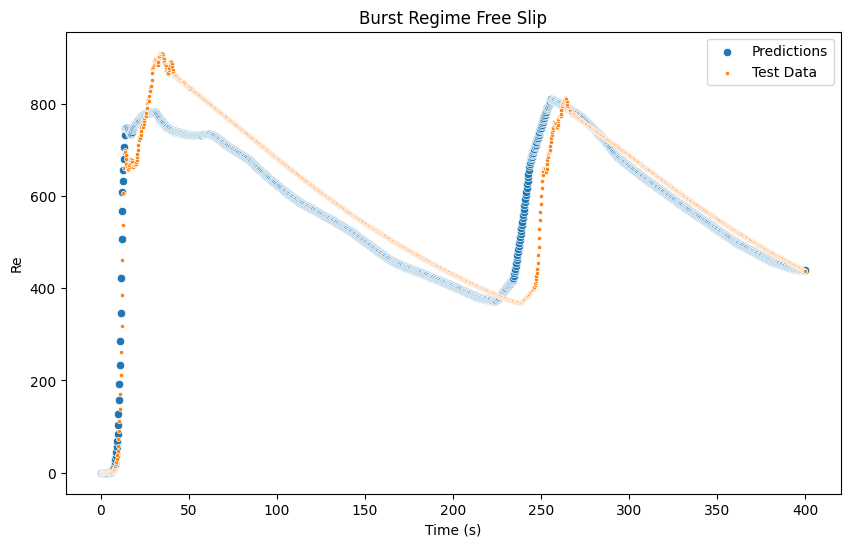

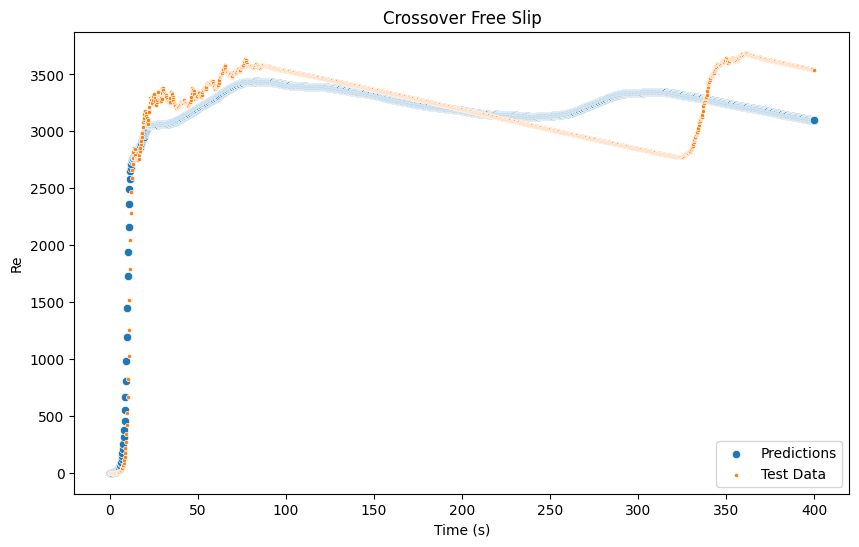

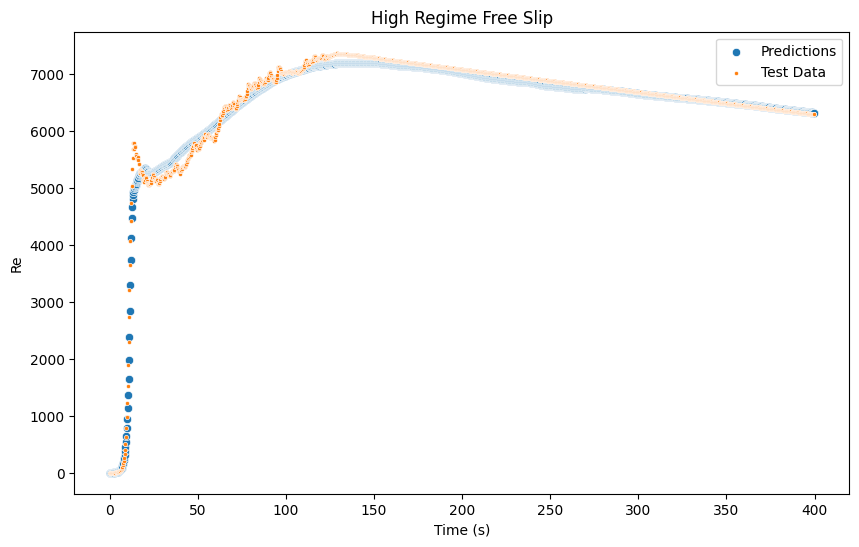

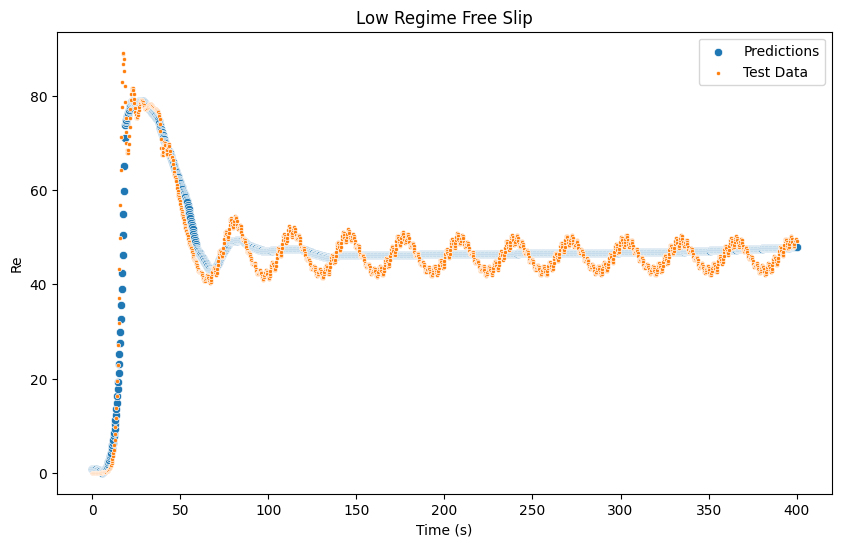

In [96]:
test_sets = [test_df, test_df2, test_df3, test_df4]

for dataset in test_sets:
    pred1 = RSNN(dataset)
    regime_lab = indentifier(dataset)
    plt.figure(figsize=(10, 6))
    plt.title(f'{regime_lab} Free Slip')
    plt.xlabel('Time (s)')
    sns.scatterplot(x = dataset['time'], y = pred1[0], label = 'Predictions', marker = 'o')
    sns.scatterplot(x = dataset['time'], y = dataset['Re'], label = 'Test Data', marker = '.')
    plt.legend()